# Spiral Trajectory Generator (segmented)

Generates an Archimedean-spiral `(x, y, V)` trajectory for the Igor **TrajectoryLitho** panel.

- Coordinates in **metres**, corner origin (`0..field`), spiral centred at `(field/2, field/2)`.
- Voltage along the path: `V = v_amplitude * sin(k*theta + offset) + v_offset`.
- **`n_segments`**: splits the spiral into that many NaN-separated segments. The Igor litho
  engine processes one segment per out-wave, lifting/ramping the tip between segments and
  re-baselining the bias at each break. A single giant segment (`n_segments=1`) can trip the
  engine's segment machinery; raising `n_segments` makes each piece small enough to run natively.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate_spiral_trajectory(
    turns=10,
    n_points=64**2,
    k=3.0,
    offset=0.0,
    v_amplitude=8.0,
    v_offset=0.0,
    field_um=5.0,
    max_radius_um=None,
    n_segments=1,          # number of NaN-separated segments (>=1)
    filename="spiral_trajectory.txt",
    include_header=True,
):
    """Archimedean spiral (x,y,V) -> tab-delimited .txt in metres, corner origin.

    n_segments: split the path into this many segments separated by a NaN row
    (NaN NaN NaN). The engine handles one segment per out-wave (tip lifts and
    bias re-baselines between segments). Use more segments if a single-segment
    path errors in the engine.
    """
    if n_segments < 1:
        raise ValueError("n_segments must be >= 1")

    field_m = field_um * 1e-6
    cx = cy = field_m / 2.0
    if max_radius_um is None:
        max_radius_m = 0.95 * field_m / 2.0
    else:
        max_radius_m = max_radius_um * 1e-6
        if max_radius_m > field_m / 2.0:
            raise ValueError("max_radius_um exceeds half the field.")

    theta = np.linspace(0.0, turns * 2.0 * np.pi, n_points)
    theta_max = turns * 2.0 * np.pi
    a = max_radius_m / theta_max if theta_max > 0 else 0.0
    r = a * theta
    x = cx + r * np.cos(theta)
    y = cy + r * np.sin(theta)
    v = v_amplitude * np.sin(k * theta + offset) + v_offset

    if n_segments == 1:
        xs, ys, vs = x, y, v
    else:
        idx_chunks = np.array_split(np.arange(n_points), n_segments)
        xs_parts, ys_parts, vs_parts = [], [], []
        nan_row = np.array([np.nan])
        for i, chunk in enumerate(idx_chunks):
            xs_parts.append(x[chunk]); ys_parts.append(y[chunk]); vs_parts.append(v[chunk])
            if i < len(idx_chunks) - 1:
                xs_parts.append(nan_row); ys_parts.append(nan_row); vs_parts.append(nan_row)
        xs = np.concatenate(xs_parts); ys = np.concatenate(ys_parts); vs = np.concatenate(vs_parts)

    data = np.column_stack([xs, ys, vs])
    header = "X_m\tY_m\tV" if include_header else ""
    np.savetxt(filename, data, delimiter="\t", header=header, comments="# ", fmt="%.10g")

    n_breaks = n_segments - 1
    print(f"Wrote {len(xs)} rows ({n_points} points + {n_breaks} NaN breaks) to '{filename}'")
    print(f"  field = {field_um} um, center = ({field_um/2}, {field_um/2}) um")
    print(f"  segments = {n_segments} (~{n_points//n_segments} points each)")
    print(f"  outer radius = {max_radius_m*1e6:.3f} um, turns = {turns}")
    print(f"  X range: [{np.nanmin(xs)*1e6:.3f}, {np.nanmax(xs)*1e6:.3f}] um")
    print(f"  V range: [{np.nanmin(vs):.2f}, {np.nanmax(vs):.2f}] V")
    return xs, ys, vs

## Generate

Set `n_segments` to the number of pieces you want. Start with something like 20–50 and increase if the engine still errors, or decrease (toward 1) for fewer tip lifts.

In [6]:
x, y, v = generate_spiral_trajectory(
    turns        = 40,
    n_points     = 128**2,
    k            = 3.0,
    offset       = 0,
    v_amplitude  = 6.0,
    v_offset     = 0.0,
    field_um     = 2.0,
    max_radius_um= None,
    n_segments   = 100,          # <-- number of NaN-separated segments
    filename     = "spiral_segmented.txt",
)

Wrote 16483 rows (16384 points + 99 NaN breaks) to 'spiral_segmented.txt'
  field = 2.0 um, center = (1.0, 1.0) um
  segments = 100 (~163 points each)
  outer radius = 0.950 um, turns = 40
  X range: [0.062, 1.950] um
  V range: [-6.00, 6.00] V


## Visualise

Path coloured by bias; NaN breaks split the segments. Markers show start/end.

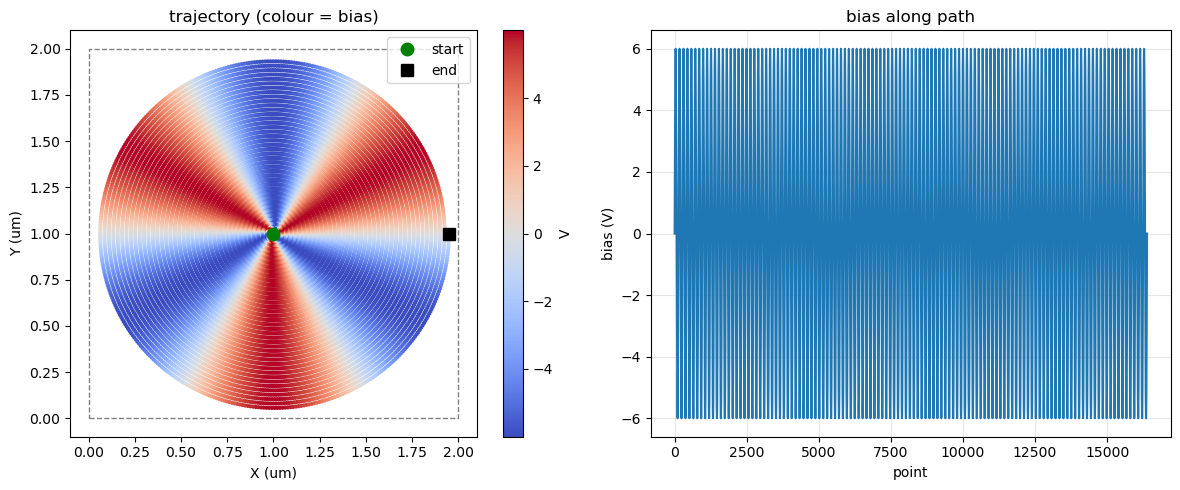

In [7]:
def visualize_trajectory(x, y, v, field_um=None):
    x = np.asarray(x); y = np.asarray(y); v = np.asarray(v)
    good = ~np.isnan(x)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sc = ax[0].scatter(x[good]*1e6, y[good]*1e6, c=v[good], s=4, cmap="coolwarm")
    ax[0].plot(x[good][0]*1e6, y[good][0]*1e6, "go", ms=9, label="start")
    ax[0].plot(x[good][-1]*1e6, y[good][-1]*1e6, "ks", ms=8, label="end")
    if field_um:
        ax[0].add_patch(plt.Rectangle((0,0), field_um, field_um, fill=False, ls="--", ec="gray"))
    ax[0].set_xlabel("X (um)"); ax[0].set_ylabel("Y (um)"); ax[0].set_aspect("equal")
    ax[0].legend(); ax[0].set_title("trajectory (colour = bias)")
    plt.colorbar(sc, ax=ax[0], label="V")
    ax[1].plot(v[good]); ax[1].set_xlabel("point"); ax[1].set_ylabel("bias (V)")
    ax[1].set_title("bias along path"); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

visualize_trajectory(x, y, v, field_um=2.0)